# Name: Shafi Azam
# Reg_No: SP24-BAI-047
# Lab: 06
# Subject: Computer Vision

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Disparity: 
Difference in pixel position between left & right images

### Depth: 
Distance of object from camera

### Stereo Vision: 
Technique to estimate depth using two images

# Activity 01: Load Stereo Images

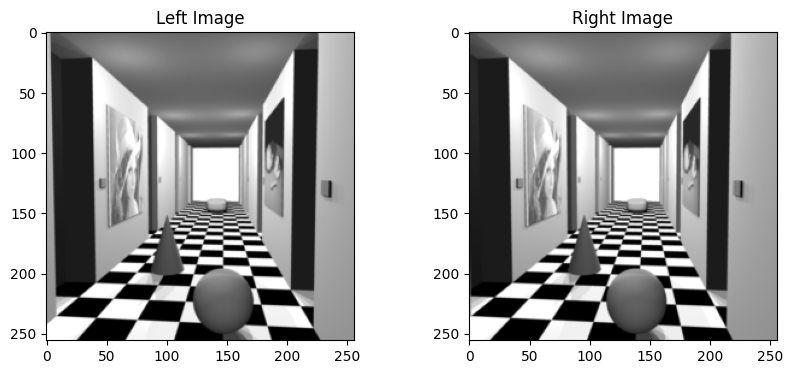

In [4]:
#load the left and right grey images
img_left = cv2.imread('D:\\VS Code\\Computer_Vision\\Lab_06_stereoVision_epipolarGeometry\\Il.jpeg', cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread('D:\\VS Code\\Computer_Vision\\Lab_06_stereoVision_epipolarGeometry\\Ir.jpeg', cv2.IMREAD_GRAYSCALE)

# display the images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_left, cmap='gray')
plt.title('Left Image')

plt.subplot(1, 2, 2)
plt.imshow(img_right, cmap='gray')
plt.title('Right Image')

plt.show()

# Activity 02: Compute Disparity Using Sum of Square Differences (SSD)

In [5]:
def compute_ssd_disparity(left, right, window_size=3, max_disp=64):
    h, w = left.shape
    disparity = np.zeros((h, w))

    offset = window_size // 2

    for y in range(offset, h-offset):
        for x in range(offset, w-offset):
            min_ssd = float('inf')
            best_disp = 0

            for d in range(max_disp):
                if x - d - offset < 0:
                    continue

                ssd = 0
                for wy in range(-offset, offset+1):
                    for wx in range(-offset, offset+1):
                        diff = int(left[y+wy, x+wx]) - int(right[y+wy, x+wx-d])
                        ssd += diff * diff

                if ssd < min_ssd:
                    min_ssd = ssd
                    best_disp = d

            disparity[y, x] = best_disp

    return disparity

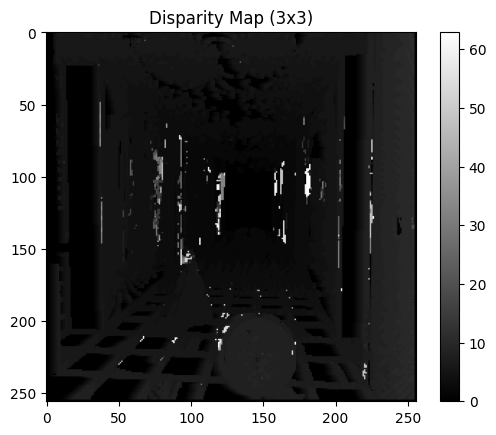

In [6]:
disp_3 = compute_ssd_disparity(img_left, img_right, window_size=3)

plt.imshow(disp_3, cmap='gray')
plt.title("Disparity Map (3x3)")
plt.colorbar()
plt.show()

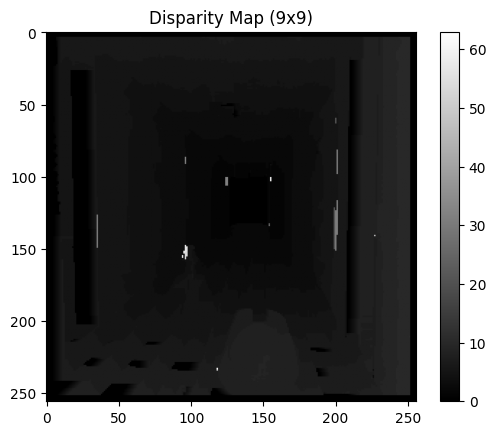

In [7]:
disp_9 = compute_ssd_disparity(img_left, img_right, window_size=9)

plt.imshow(disp_9, cmap='gray')
plt.title("Disparity Map (9x9)")
plt.colorbar()
plt.show()

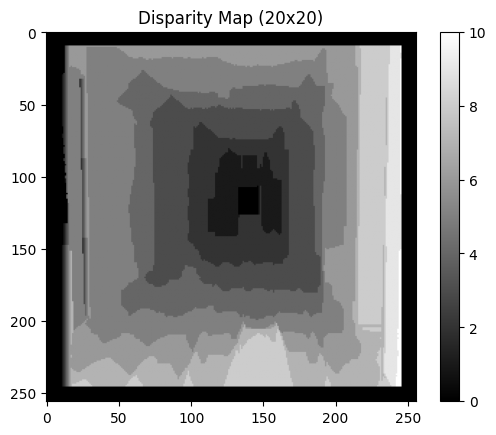

In [9]:
disp_20 = compute_ssd_disparity(img_left, img_right, window_size=20)

plt.imshow(disp_20, cmap='gray')
plt.title("Disparity Map (20x20)")
plt.colorbar()
plt.show()

# Activity 3: Compute Disparity Map Using Formula

In [10]:
def compute_depth(disparity, B=0.54, f=721):
    depth = np.zeros_like(disparity)

    for i in range(disparity.shape[0]):
        for j in range(disparity.shape[1]):
            if disparity[i,j] > 0:
                depth[i,j] = (B * f) / disparity[i,j]
            else:
                depth[i,j] = 0

    return depth

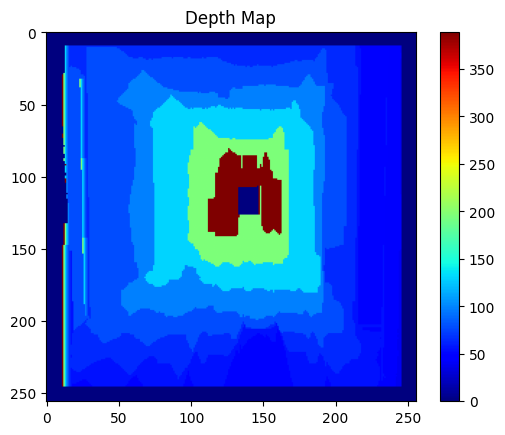

In [11]:
depth_map = compute_depth(disp_20)

plt.imshow(depth_map, cmap='jet')
plt.title("Depth Map")
plt.colorbar()
plt.show()

# Activity 4: Build Depth Map

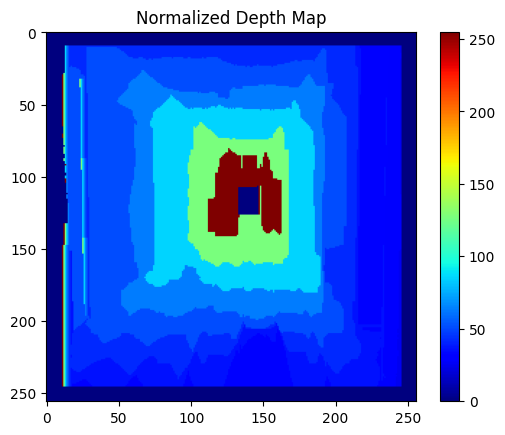

In [12]:
# Normalize for display
depth_normalized = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX)
depth_normalized = np.uint8(depth_normalized)

plt.imshow(depth_normalized, cmap='jet')
plt.title("Normalized Depth Map")
plt.colorbar()
plt.show()

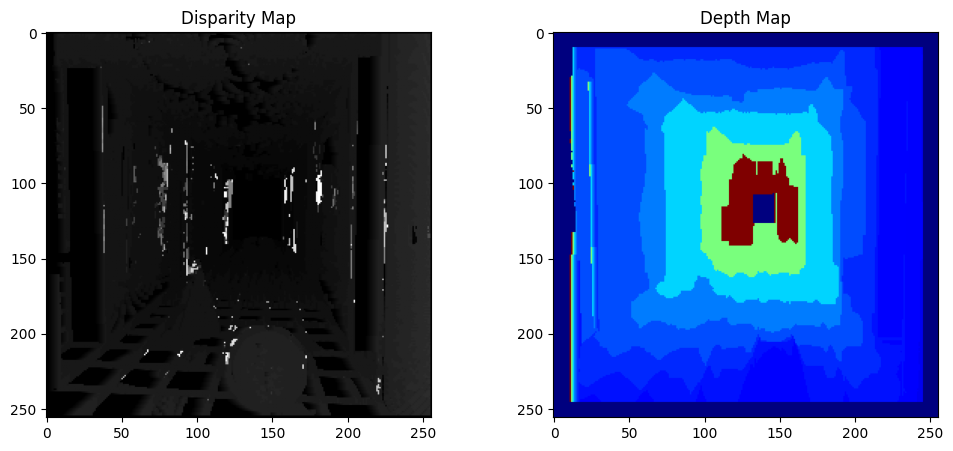

In [13]:
# Compare Disparity vs Depth
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(disp_3, cmap='gray')
plt.title("Disparity Map")

plt.subplot(1,2,2)
plt.imshow(depth_normalized, cmap='jet')
plt.title("Depth Map")

plt.show()

# Activity 4 Explanation:

The depth map is visualized using color mapping.

1. Closer objects → higher disparity → smaller depth values

2. Far objects → lower disparity → larger depth values

Normalization is required to convert depth into displayable range (0–255).

Color maps like jet help in better interpretation of distance.

## Conclusion:

Bright regions (red/yellow) = near objects

Dark regions (blue) = far objects

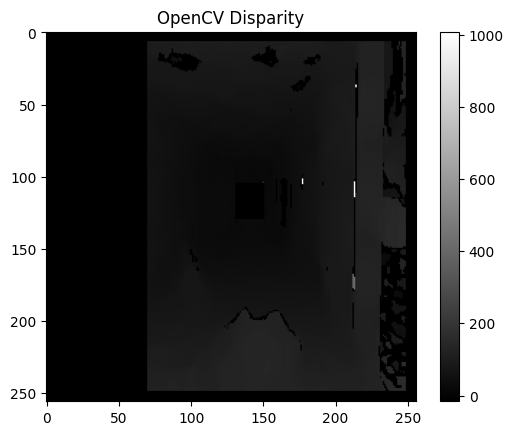

In [14]:
# Using OpenCV (Better Result)
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disp_cv = stereo.compute(img_left, img_right)

plt.imshow(disp_cv, cmap='gray')
plt.title("OpenCV Disparity")
plt.colorbar()
plt.show()

# Task: 01
1. Objects closer than threshold are considered obstacles

2. Depth map is thresholded to detect obstacles

3. Bounding boxes are drawn around detected regions

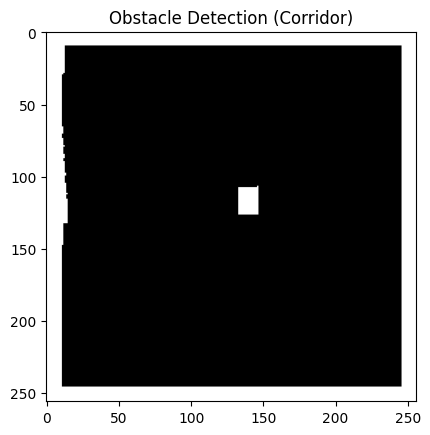

In [15]:
# detect obstacles

# Threshold depth to detect close objects (obstacles)

threshold = 2.0   # meters

obstacle_mask = depth_map < threshold

plt.imshow(obstacle_mask, cmap='gray')
plt.title("Obstacle Detection (Corridor)")
plt.show()

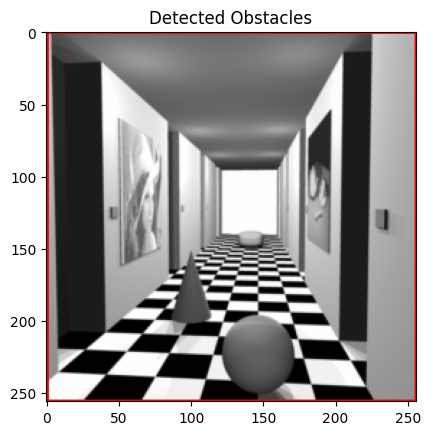

In [16]:
# highlight obstacles on the original image

# Convert to uint8 for contour detection
mask = np.uint8(obstacle_mask * 255)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Convert grayscale to color for drawing
img_color = cv2.cvtColor(img_left, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_color, (x,y), (x+w, y+h), (0,0,255), 2)

plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Detected Obstacles")
plt.show()

# Task 2: Augmented Reality (AR Placement)
1. Depth map is used to estimate object distance

2. Virtual object is placed at selected pixel

3. Distance is displayed using depth formula

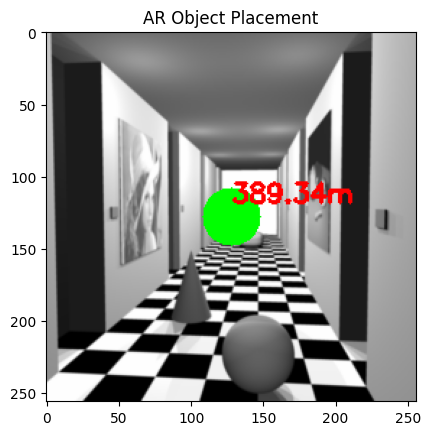

In [17]:
# Choose a pixel (center)
h, w = depth_map.shape
x, y = w//2, h//2

distance = depth_map[y, x]

# Convert image to color
img_ar = cv2.cvtColor(img_left, cv2.COLOR_GRAY2BGR)

# Draw virtual object (circle)
cv2.circle(img_ar, (x,y), 20, (0,255,0), -1)

# Show distance
cv2.putText(img_ar, f"{distance:.2f}m", (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

plt.imshow(cv2.cvtColor(img_ar, cv2.COLOR_BGR2RGB))
plt.title("AR Object Placement")
plt.show()

# Task 3: Traffic Monitoring (Vehicle Distance)
1. Depth map is used to estimate vehicle distance

2. Regions are detected using thresholding

3. Distance is calculated using median depth

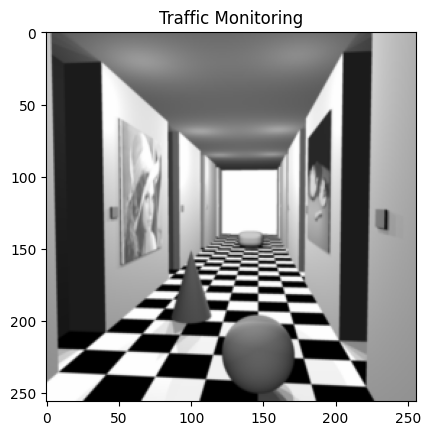

In [18]:
# Assume vehicles are within certain distance
mask = (depth_map > 0) & (depth_map < 20)

mask = np.uint8(mask * 255)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_traffic = cv2.cvtColor(img_left, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:   # filter small noise
        x, y, w, h = cv2.boundingRect(cnt)

        # estimate distance
        region = depth_map[y:y+h, x:x+w]
        distance = np.median(region)

        cv2.rectangle(img_traffic, (x,y), (x+w,y+h), (255,0,0), 2)
        cv2.putText(img_traffic, f"{distance:.2f}m", (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 2)

plt.imshow(cv2.cvtColor(img_traffic, cv2.COLOR_BGR2RGB))
plt.title("Traffic Monitoring")
plt.show()

# Task 4: Medical Imaging (Stereo Depth)
1. Depth map helps visualize internal structures

2. Close regions represent important tissues

3. Useful in surgical navigation and diagnosis

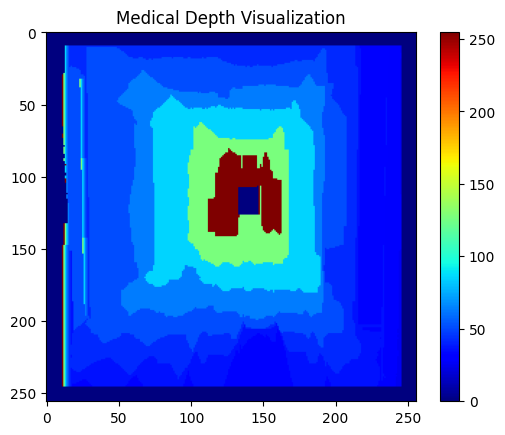

In [19]:
# Normalize depth for visualization
depth_norm = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX)
depth_norm = np.uint8(depth_norm)

plt.imshow(depth_norm, cmap='jet')
plt.title("Medical Depth Visualization")
plt.colorbar()
plt.show()

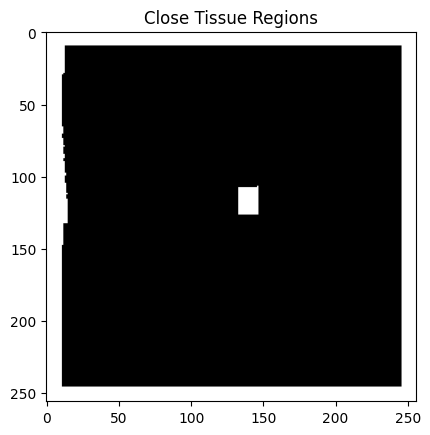

In [20]:
# Highlight very close regions (like tissues)

mask = depth_map < 0.5   # very near

plt.imshow(mask, cmap='gray')
plt.title("Close Tissue Regions")
plt.show()

# FINAL CONCLUSION

1. Stereo vision is used to estimate depth from two images

2. Disparity is inversely proportional to depth

3. Larger disparity → closer object

4. Depth maps enable real-world applications:

    1. Obstacle detection

    2. AR systems

    3. Traffic monitoring

    4. Medical imaging